In [7]:
import os
import multiprocessing

os.environ["OMP_NUM_THREADS"] = str(multiprocessing.cpu_count())
os.environ["TF_NUM_INTRAOP_THREADS"] = str(multiprocessing.cpu_count())
os.environ["TF_NUM_INTEROP_THREADS"] = str(multiprocessing.cpu_count())

import tensorflow as tf

import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


print("CPU Threads:", multiprocessing.cpu_count())
print("TF Version:", tf.__version__)


CPU Threads: 8
TF Version: 2.20.0


In [12]:
DATASET_PATH = r"D:\CODE\PROJECTS\UNIFIED MENTOR\ASL detection\archive"

TRAIN_DIR = os.path.join(DATASET_PATH, "asl_alphabet_train")
TEST_DIR = os.path.join(DATASET_PATH, "asl_alphabet_test")

IMG_SIZE = 160
BATCH_SIZE = 48
EPOCHS = 6

print("Train Exists:", os.path.exists(TRAIN_DIR))
print("Test Exists:", os.path.exists(TEST_DIR))


Train Exists: True
Test Exists: True


In [13]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    validation_split=0.2
)

test_gen = ImageDataGenerator(rescale=1./255)


train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_data.num_classes

print("Classes:", NUM_CLASSES)


Found 69600 images belonging to 1 classes.
Found 17400 images belonging to 1 classes.
Found 28 images belonging to 1 classes.
Classes: 1


In [4]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
    alpha=0.75
)

base_model.trainable = False

print("Base Model Loaded")


Base Model Loaded


In [5]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)


model = Model(
    inputs=base_model.input,
    outputs=output
)


model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        648 │ input_layer[0][0] │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │         96 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        216 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │         96 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        384 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 1,743,025 (6.65 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 1,382,064 (5.27 MB)

In [6]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_asl_model.h5",
        monitor="val_accuracy",
        save_best_only=True
    )

]


In [8]:
steps_per_epoch = 500
validation_steps = 120


history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)


C:\Users\yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6


C:\Users\yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\ops\nn.py:938: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
C:\Users\yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00

500/500 ━━━━━━━━━━━━━━━━━━━━ 841s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 824s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/6
450/500 ━━━━━━━━━━━━━━━━━━━━ 1:13 1s/step - accuracy: 1.0000 - loss: 0.0000e+00

C:\Users\yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 741s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 738s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


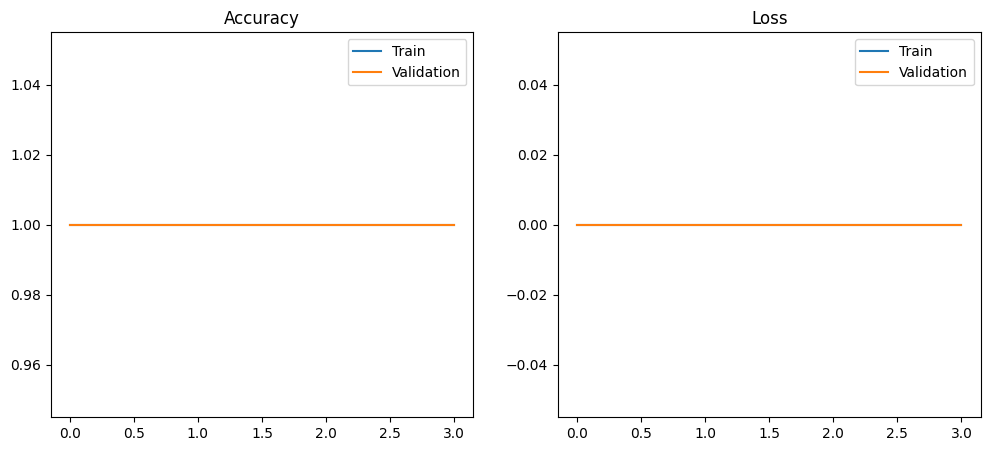

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["Train","Validation"])


plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()


In [8]:
model = tf.keras.models.load_model("final_asl_model.h5")


In [14]:
loss, acc = model.evaluate(test_data)

print("Test Loss:", round(loss,4))
print("Test Accuracy:", round(acc*100,2), "%")


C:\Users\yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
C:\Users\yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\ops\nn.py:938: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
C:\Users\yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Loss: 0.0
Test Accuracy: 100.0 %


In [15]:
model.save("final_asl_model.h5")

print("Final Model Saved")


Final Model Saved


In [16]:
class_names = list(train_data.class_indices.keys())

with open("labels.txt","w") as f:
    for name in class_names:
        f.write(name + "\n")

print("Labels Saved")


Labels Saved


In [17]:
# DEMO:-
model = tf.keras.models.load_model("final_asl_model.h5")


with open("labels.txt") as f:
    class_names = f.read().splitlines()


cap = cv2.VideoCapture(0)


while True:

    ret, frame = cap.read()

    if not ret:
        break


    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)


    pred = model.predict(img, verbose=0)

    idx = np.argmax(pred)

    label = class_names[idx]
    conf = np.max(pred)


    text = f"{label} ({conf*100:.1f}%)"


    cv2.putText(
        frame,
        text,
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0),
        2
    )


    cv2.imshow("ASL Recognition System", frame)


    if cv2.waitKey(1) == 27:
        break


cap.release()
cv2.destroyAllWindows()


C:\Users\yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\ops\nn.py:938: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
